In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
import sys
sys.path.append("..")

from src.siac_modal import *
from src.research_utils_1d import *

In [6]:

# ============================================================
# 1. Reference no-split BSInt computation
# ============================================================

def grab_integrals_nosplit(eval_nodes, p, BSorder, BSsupport, quad_order=40):
    """
    Direct reference implementation of the SIAC integrals, without splitting.

    Returns
    -------
    BSInt : ndarray, shape (p+1, BSlen, n_eval)
    """
    eval_nodes = np.asarray(eval_nodes, dtype=float)
    order = p + 1
    n_eval = len(eval_nodes)

    BSmin, BSmax = int(BSsupport[0]), int(BSsupport[1])
    BSlen = BSmax - BSmin + 1

    B = centered_cardinal_bspline(BSorder)
    q_ref, w_ref = leggauss(quad_order)
    phi = eval_orthonormal_legendre_1d(q_ref, p)   # (order, nq)

    BSInt = np.zeros((order, BSlen, n_eval), dtype=float)

    for k, zeta in enumerate(eval_nodes):
        for i in range(BSmin, BSmax + 1):
            j = i - BSmin
            kernel = B(0.5 * (zeta - q_ref) - i)
            BSInt[:, j, k] = 0.5 * np.sum(phi * (w_ref * kernel)[None, :], axis=1)

    return BSInt


# ============================================================
# 2. BSInt comparison check
# ============================================================

def check_grab_integrals_vs_direct(
    eval_nodes,
    p,
    BSorder,
    BSsupport,
    quad_order_split=40,
    quad_order_direct=60,
    verbose=False,
):
    """
    Compare split-based grab_integrals against a direct no-split reference.
    """
    BSInt_split = grab_integrals(
        eval_nodes=eval_nodes,
        p=p,
        BSorder=BSorder,
        BSsupport=BSsupport,
        quad_order=quad_order_split,
    )

    BSInt_direct = grab_integrals_nosplit(
        eval_nodes=eval_nodes,
        p=p,
        BSorder=BSorder,
        BSsupport=BSsupport,
        quad_order=quad_order_direct,
    )

    diff = BSInt_split - BSInt_direct
    max_abs = np.max(np.abs(diff))
    rel = np.linalg.norm(diff.ravel()) / max(np.linalg.norm(BSInt_direct.ravel()), 1e-15)

    print("=== CHECK 1: grab_integrals vs direct no-split quadrature ===")
    print(f"shape                 : {BSInt_split.shape}")
    print(f"max abs difference    : {max_abs:.3e}")
    print(f"relative Frobenius err: {rel:.3e}")
    print(f"all finite?           : {np.isfinite(BSInt_split).all()}")

    if verbose:
        idx = np.unravel_index(np.argmax(np.abs(diff)), diff.shape)
        m, j, k = idx
        print(f"worst entry at (m,j,k)=({m},{j},{k})")
        print(f"split  = {BSInt_split[idx]:+.16e}")
        print(f"direct = {BSInt_direct[idx]:+.16e}")
        print(f"diff   = {diff[idx]:+.16e}")

    return BSInt_split, BSInt_direct, diff


# ============================================================
# 3. Symmetry / parity check
# ============================================================

def check_bsint_symmetry(BSInt, eval_nodes, p):
    """
    For symmetric eval nodes, check:
        BSInt[m, :, k] ~ (-1)^m * reversed(BSInt[m, :, k_mirror])
    """
    eval_nodes = np.asarray(eval_nodes, dtype=float)

    print("\n=== CHECK 2: symmetry / parity structure ===")
    max_err = 0.0

    for k, zeta in enumerate(eval_nodes):
        k_mirror = np.argmin(np.abs(eval_nodes + zeta))
        zeta_mirror = eval_nodes[k_mirror]

        for m in range(p + 1):
            lhs = BSInt[m, :, k]
            rhs = ((-1) ** m) * BSInt[m, ::-1, k_mirror]
            err = np.max(np.abs(lhs - rhs))
            max_err = max(max_err, err)

            print(
                f"zeta={zeta:+.6f}, mirror={zeta_mirror:+.6f}, "
                f"mode={m}, sym err={err:.3e}"
            )

    print(f"max symmetry/parity error: {max_err:.3e}")
    return max_err


# ============================================================
# 4. Optional plotting
# ============================================================

def plot_bsint_slices(BSInt, eval_nodes, BSsupport, p, modes=None):
    """
    Plot BSInt[m, :, k] against shift index for selected modes.
    """
    if modes is None:
        modes = list(range(p + 1))

    shifts = np.arange(int(BSsupport[0]), int(BSsupport[1]) + 1)
    eval_nodes = np.asarray(eval_nodes, dtype=float)

    k_center = np.argmin(np.abs(eval_nodes))
    zeta = eval_nodes[k_center]

    print("\n=== OPTIONAL PLOT: BSInt slices at center/nearest-center node ===")
    print(f"Using k={k_center}, zeta={zeta:+.6f}")

    for m in modes:
        plt.figure(figsize=(6, 4))
        plt.plot(shifts, BSInt[m, :, k_center], marker="o")
        plt.axhline(0.0, linewidth=1)
        plt.title(f"BSInt[m,:,k] for mode m={m}, zeta={zeta:+.6f}")
        plt.xlabel("shift index")
        plt.ylabel("integral value")
        plt.grid(True)
        plt.show()


# ============================================================
# 5. Exact monomial on physical domain
# ============================================================

def exact_monomial_scaled_1d(x, degree, xlim=(-1, 1)):
    """
    u(x) = xhat^degree, where xhat maps xlim -> [-1,1]
    """
    x = np.asarray(x, dtype=float)
    xhat = 2.0 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    return xhat ** degree


# ============================================================
# 6. Main polynomial test on a genuinely fine grid
# ============================================================

def test_siac_polynomial_reproduction_1d(
    K=64,
    p=2,
    max_degree=None,
    xlim=(-1, 1),
    moments=None,
    BSorder=None,
    fine_factor=8,
    exclude_width=None,
):
    """
    Test DG and SIAC on monomials, evaluated on a fine grid per element.

    This is a real approximation/reproduction test, not just nodal roundtrip.

    Parameters
    ----------
    K : int
        Number of elements.
    p : int
        DG polynomial degree.
    max_degree : int or None
        Highest monomial degree to test. Defaults to 2*p + 2.
    xlim : tuple
        Domain.
    moments : int or None
        Defaults to 2*p.
    BSorder : int or None
        Defaults to p+1.
    fine_factor : int
        Number of fine evaluation points per DG node count, i.e.
        n_eval = fine_factor * (p+1)
    exclude_width : int or None
        Number of elements excluded on each side for SIAC validity.
        Defaults to halfker + 1.

    Returns
    -------
    results : list[dict]
    """
    if moments is None:
        moments = 2 * p
    if BSorder is None:
        BSorder = p + 1
    if max_degree is None:
        max_degree = 2 * p + 2

    order = p + 1
    n_eval = fine_factor * order

    mesh = build_mesh_1d(K=K, domain=xlim)

    # DG interpolation nodes
    dg_nodes = local_cell_center_nodes_1d(order)
    _, x_blocks_dg = build_grid_from_local_nodes_1d(mesh, dg_nodes, return_blocks=True)

    # Fine evaluation nodes
    fine_nodes = local_cell_center_nodes_1d(n_eval)
    x_eval, x_blocks_eval = build_grid_from_local_nodes_1d(mesh, fine_nodes, return_blocks=True)

    # SIAC kernel half-width in element units
    halfker = int(np.ceil((moments + BSorder) / 2))
    if exclude_width is None:
        exclude_width = halfker + 1

    print("\n=== CHECK 3: polynomial reproduction by DG + SIAC on fine grid ===")
    print(f"K={K}, p={p}, moments={moments}, BSorder={BSorder}, n_eval={n_eval}")
    print(f"exclude_width = {exclude_width} elements on each side")

    if 2 * exclude_width >= K:
        raise ValueError("exclude_width too large relative to K.")

    results = []

    for deg in range(max_degree + 1):
        # Build DG from elementwise nodal samples
        Unode = exact_monomial_scaled_1d(x_blocks_dg, degree=deg, xlim=xlim)
        dg = nodal_to_modal_1d(Unode=Unode, mesh=mesh, p=p)

        # Evaluate DG on fine grid
        arr_dg, blocks_dg_eval = eval_dg_modal_local_nodes_1d(
            dg, eval_nodes=fine_nodes, return_blocks=True
        )

        # Evaluate SIAC on same fine grid
        arr_siac, blocks_siac = apply_siac_modal_dg_local_nodes_1d(
            dg,
            moments=moments,
            BSorder=BSorder,
            eval_nodes=fine_nodes,
            return_blocks=True,
        )

        # Exact on fine grid
        exact_blocks = exact_monomial_scaled_1d(x_blocks_eval, degree=deg, xlim=xlim)

        # Interior only
        sl = slice(exclude_width, K - exclude_width)

        dg_err = blocks_dg_eval[sl, :] - exact_blocks[sl, :]
        siac_err = blocks_siac[sl, :] - exact_blocks[sl, :]
        exact_int = exact_blocks[sl, :]

        dg_max = np.max(np.abs(dg_err))
        siac_max = np.max(np.abs(siac_err))

        dg_rel = np.linalg.norm(dg_err.ravel()) / max(np.linalg.norm(exact_int.ravel()), 1e-15)
        siac_rel = np.linalg.norm(siac_err.ravel()) / max(np.linalg.norm(exact_int.ravel()), 1e-15)

        print(
            f"deg={deg:2d} | "
            f"DG max={dg_max:.3e}, DG relL2={dg_rel:.3e} | "
            f"SIAC max={siac_max:.3e}, SIAC relL2={siac_rel:.3e}"
        )

        results.append({
            "degree": deg,
            "dg_max": dg_max,
            "dg_relL2": dg_rel,
            "siac_max": siac_max,
            "siac_relL2": siac_rel,
        })

    return results


# ============================================================
# 7. Wrapper
# ============================================================

def run_all_bsint_debug_checks(
    p=2,
    BSorder=None,
    moments=None,
    eval_nodes=None,
    quad_order_split=40,
    quad_order_direct=60,
    do_plots=True,
):
    """
    Run the BSInt/integral checks.
    """
    if BSorder is None:
        BSorder = p + 1
    if moments is None:
        moments = 2 * p
    if eval_nodes is None:
        eval_nodes = local_cell_center_nodes_1d(p + 1)

    BSknots = np.linspace(-BSorder / 2, BSorder / 2, BSorder + 1)
    BSsupport = np.array([np.floor(BSknots[0]), np.ceil(BSknots[-1])], dtype=int)

    print("============================================================")
    print("Running BSInt / SIAC debug checks")
    print("============================================================")
    print(f"p         = {p}")
    print(f"moments   = {moments}")
    print(f"BSorder   = {BSorder}")
    print(f"eval_nodes= {np.asarray(eval_nodes)}")
    print(f"BSsupport = {BSsupport}")

    BSInt_split, BSInt_direct, diff = check_grab_integrals_vs_direct(
        eval_nodes=eval_nodes,
        p=p,
        BSorder=BSorder,
        BSsupport=BSsupport,
        quad_order_split=quad_order_split,
        quad_order_direct=quad_order_direct,
        verbose=True,
    )

    check_bsint_symmetry(BSInt_split, eval_nodes, p)

    if do_plots:
        plot_bsint_slices(BSInt_split, eval_nodes, BSsupport, p)

    return {
        "BSInt_split": BSInt_split,
        "BSInt_direct": BSInt_direct,
        "diff": diff,
        "BSsupport": BSsupport,
    }

Running BSInt / SIAC debug checks
p         = 4
moments   = 4
BSorder   = 3
eval_nodes= [-0.8 -0.4  0.   0.4  0.8]
BSsupport = [-2  2]
=== CHECK 1: grab_integrals vs direct no-split quadrature ===
shape                 : (5, 5, 5)
max abs difference    : 1.735e-07
relative Frobenius err: 7.214e-07
all finite?           : True
worst entry at (m,j,k)=(2,2,0)
split  = -2.7608792158378224e-02
direct = -2.7608965660250895e-02
diff   = +1.7350187267103911e-07

=== CHECK 2: symmetry / parity structure ===
zeta=-0.800000, mirror=+0.800000, mode=0, sym err=5.551e-17
zeta=-0.800000, mirror=+0.800000, mode=1, sym err=2.776e-17
zeta=-0.800000, mirror=+0.800000, mode=2, sym err=3.469e-17
zeta=-0.800000, mirror=+0.800000, mode=3, sym err=6.939e-18
zeta=-0.800000, mirror=+0.800000, mode=4, sym err=7.633e-17
zeta=-0.400000, mirror=+0.400000, mode=0, sym err=5.551e-17
zeta=-0.400000, mirror=+0.400000, mode=1, sym err=2.776e-17
zeta=-0.400000, mirror=+0.400000, mode=2, sym err=2.776e-17
zeta=-0.400000, 

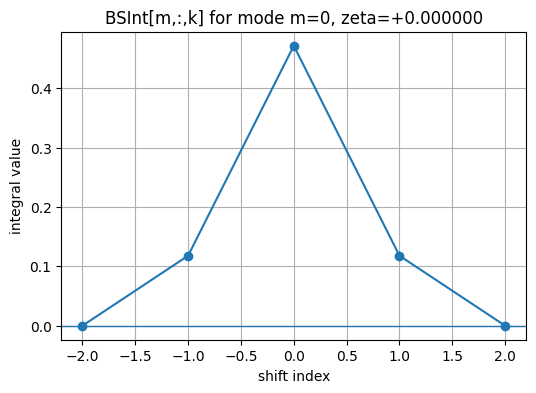

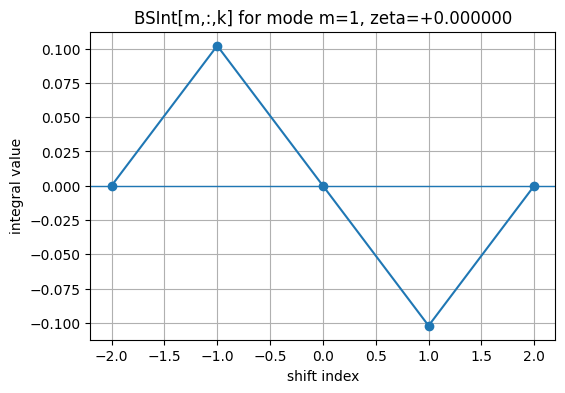

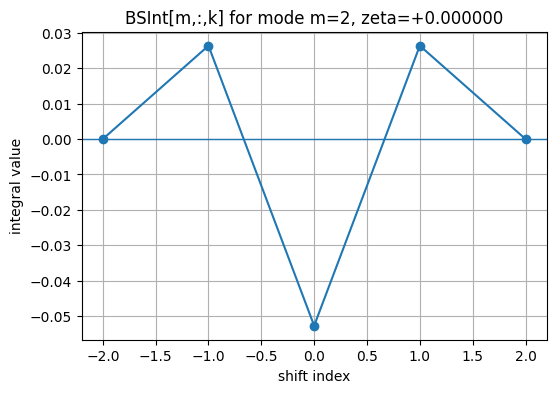

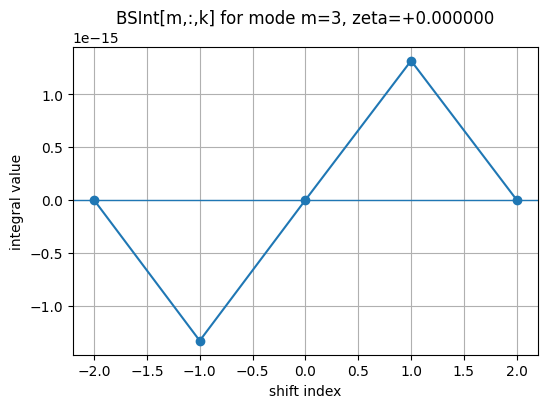

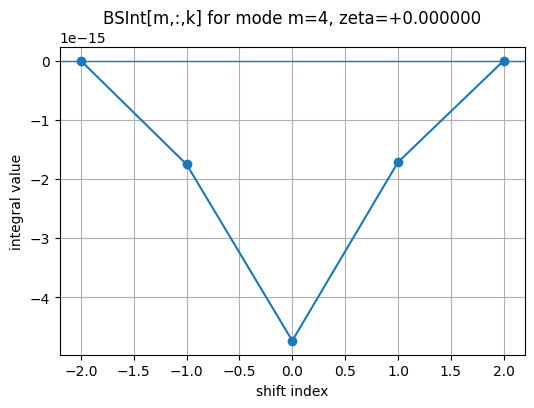

In [7]:

p = 4
order = p + 1
moments = 4
BSorder = 3

out = run_all_bsint_debug_checks(
    p=p,
    BSorder=BSorder,
    moments=moments,
    eval_nodes=local_cell_center_nodes_1d(order),
    quad_order_split=40,
    quad_order_direct=60,
    do_plots=True,
)

In [9]:
# mesh and polynomial degree for reproduction test
K = 64
max_degree = 7
# DG stuff
p = 4
order = p + 1
# SIAC stuff
moments = 4
BSorder = 3

results = test_siac_polynomial_reproduction_1d(
    K=K,
    p=p,
    max_degree=max_degree,
    xlim=(-1, 1),
    moments=moments,
    BSorder=BSorder,
    fine_factor=8,
)


=== CHECK 3: polynomial reproduction by DG + SIAC on fine grid ===
K=64, p=4, moments=4, BSorder=3, n_eval=40
exclude_width = 5 elements on each side
deg= 0 | DG max=6.661e-16, DG relL2=2.616e-16 | SIAC max=4.441e-16, SIAC relL2=1.923e-16
deg= 1 | DG max=5.551e-16, DG relL2=2.888e-16 | SIAC max=4.441e-16, SIAC relL2=2.048e-16
deg= 2 | DG max=6.661e-16, DG relL2=3.248e-16 | SIAC max=4.441e-16, SIAC relL2=2.640e-16
deg= 3 | DG max=5.551e-16, DG relL2=3.512e-16 | SIAC max=3.331e-16, SIAC relL2=2.827e-16
deg= 4 | DG max=3.886e-16, DG relL2=4.073e-16 | SIAC max=3.886e-16, SIAC relL2=3.430e-16
deg= 5 | DG max=2.230e-10, DG relL2=4.778e-10 | SIAC max=3.886e-16, SIAC relL2=4.141e-16
deg= 6 | DG max=1.111e-09, DG relL2=1.799e-09 | SIAC max=2.239e-09, SIAC relL2=2.237e-08
deg= 7 | DG max=3.231e-09, DG relL2=5.238e-09 | SIAC max=1.322e-08, SIAC relL2=9.712e-08
